# Forecasting Next-Day PM2.5 in Dublin Using Mobile Air Quality, Weather, and Traffic Data

**Research question:**

Can next-day air pollution in Dublin be predicted from recent pollution levels, weather and traffic conditions, and what does this imply for DCC’s monitoring and intervention strategy?

**Target variable:** 

Particulate matter pollution, specifically PM2.5, particles with a size (diameter) of less than 2.5 micrometers 

**Rationale for PM2.5**

PM2.5 is used as the dependent variable because particulate matter is identified by Our World in Data as the main contributor to poor health from air pollution, with higher death rates than ozone, and PM2.5 is especially harmful because its very small particles can penetrate deep into the respiratory system.

**Data sources**

- Google Air View
- weather dataset *(Met Eirean Daily Historical Data at Dublin Airport)*
- traffic dataset *(TBD)*

## 1. Setup

- imports
- random seed
- file paths

In [22]:
#Import Libraries

#Basic
%matplotlib inline
import numpy as np
import pandas as pd
import math
from pathlib import Path


#Plotting
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#Testing Ellen that it works

## 2. Data loading understanding
- variable overview
- time coverage
- granularity
- missingness

### 2.1 Air View data understanding & exploration

In [3]:
data_airview = pd.read_csv('../data/raw/AirView_DublinCity_Measurements_ugm3.csv')

In [4]:
print(data_airview.shape)

(5030143, 15)


In [5]:
print(data_airview.columns)

Index(['gps_timestamp', 'latitude', 'longitude', 'NO_ugm3', 'NO2_ugm3',
       'O3_ugm3', 'CO_mgm3', 'CO2_mgm3', 'PMch1_perL', 'PMch2_perL',
       'PMch3_perL', 'PMch4_perL', 'PMch5_perL', 'PMch6_perL', 'PM25_ugm3'],
      dtype='object')


In [6]:
#Stripped DF with just PM2.5 ugm^3 and car metrics
df = data_airview[['gps_timestamp', 'latitude' , 'longitude' , 'PM25_ugm3']]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5030143 entries, 0 to 5030142
Data columns (total 4 columns):
 #   Column         Dtype  
---  ------         -----  
 0   gps_timestamp  object 
 1   latitude       float64
 2   longitude      float64
 3   PM25_ugm3      float64
dtypes: float64(3), object(1)
memory usage: 153.5+ MB


In [7]:
df = df.copy()
df.loc[:, "timestamp"] = pd.to_datetime(
    df["gps_timestamp"],
    format="%Y-%m-%d %H:%M:%S %Z"
)

In [8]:
#Check for missingness
df.isna().sum()

gps_timestamp        0
latitude             0
longitude            0
PM25_ugm3        89877
timestamp            0
dtype: int64

In [9]:
#Determine the percentage of rows with missing PM2.5 recordings
missing_rows = df[df["PM25_ugm3"].isna()] #highlight row mask for plotting

percentage_missing = len(missing_rows) / len(df) * 100
print(round(percentage_missing,2), "% of all rows have missing PM2.5 values")

1.79 % of all rows have missing PM2.5 values


In [10]:
#For easy plotting add date /time column
df['date'] = df['timestamp'].dt.date
df['time'] = df['timestamp'].dt.time

In [11]:
# Basic time stats
print("Date range:", df['date'].min(), "to", df['date'].max())

total_days = (df['date'].max() - df['date'].min()).days + 1 #add 1 for  both first/last day
observed_days = df["date"].nunique() #unique dates
percentage_days = (observed_days / total_days) * 100

print(f"The car took readings on {observed_days} days out of the total {total_days} days in range"
      f"({percentage_days:.2f}% of days)")

Date range: 2021-05-06 to 2022-08-05
The car took readings on 286 days out of the total 457 days in range(62.58% of days)


In [12]:
# Car times of day
print("Time range:", df['time'].min(), "to", df['time'].max())

Time range: 06:11:07 to 19:43:31


In [13]:
#Days of week recordings
df['weekday'] = df['timestamp'].dt.day_name()
weekday_counts = df['weekday'].value_counts().reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])
print(weekday_counts)

weekday
Monday        912416.0
Tuesday      1132047.0
Wednesday    1019297.0
Thursday     1009116.0
Friday        957267.0
Saturday           NaN
Sunday             NaN
Name: count, dtype: float64


Evidently the car only captured measurements on weekdays, with Tuesday having the largest number of recordings. On average, Monday and Friday have the lowest number of recordings of all the weekdays.

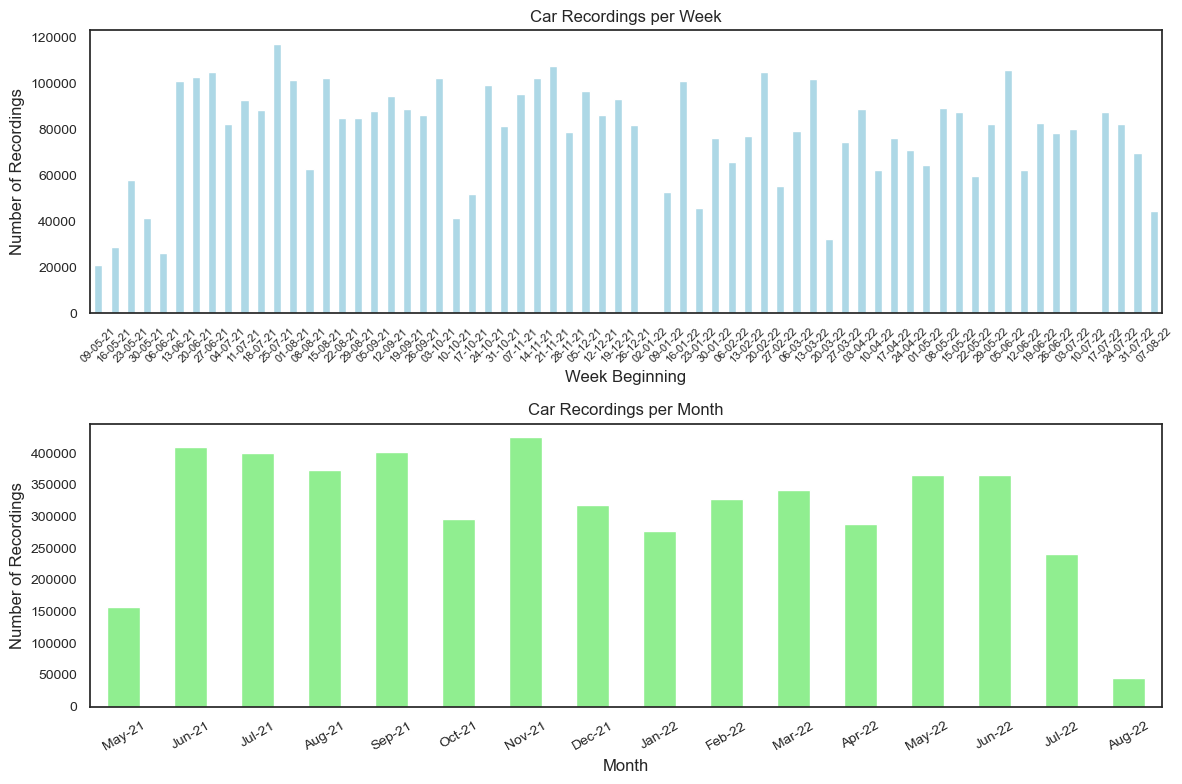

In [14]:
#Visualise recordings weekly and monthly
df['date'] = pd.to_datetime(df['date'])
weekly_counts = df.groupby(pd.Grouper(key = 'date', freq = 'W')).size()
monthly_counts = df.groupby(pd.Grouper(key = 'date', freq = 'ME')).size()

#Both in subplots
sns.set_theme(style="white")
fig, axes = plt.subplots(2, 1, figsize=(12, 8))  # 2x1

# Weekly plot
weekly_counts.index = weekly_counts.index.strftime('%d-%m-%y')
weekly_counts.plot(ax=axes[0], kind='bar', color = 'lightblue')
axes[0].set_title('Car Recordings per Week')
axes[0].set_xlabel('Week Beginning')
axes[0].set_ylabel('Number of Recordings')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', labelsize=10)

# Monthly plot
monthly_counts.index = monthly_counts.index.strftime('%b-%y')
monthly_counts.plot(ax=axes[1], kind='bar', color = 'lightgreen')
axes[1].set_title('Car Recordings per Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Recordings')
axes[1].tick_params(axis='x', rotation=30, labelsize=10)
axes[1].tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()

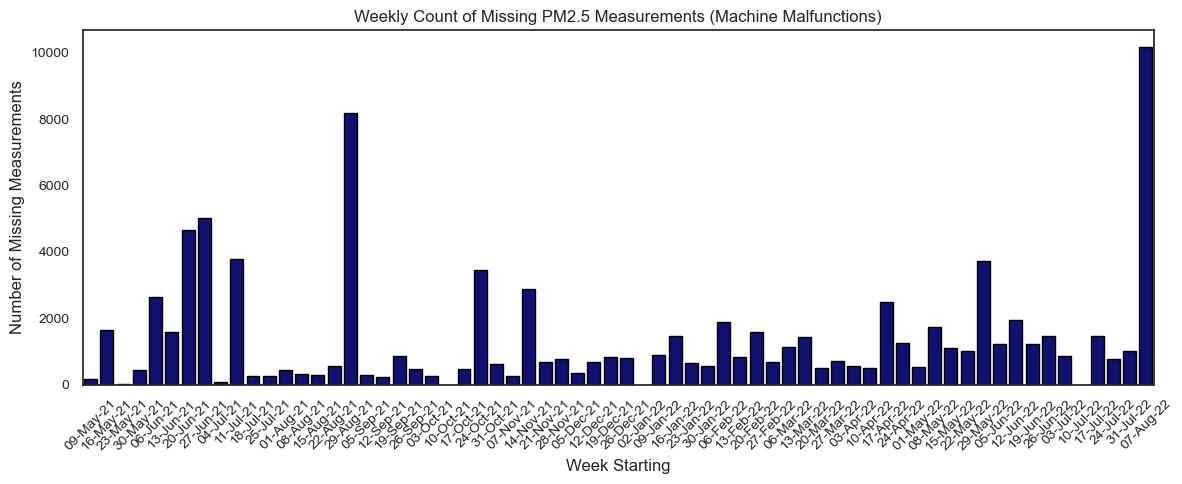

In [15]:
# Distribution of missing values

weekly_missing = df.groupby(pd.Grouper(key = 'timestamp', freq = 'W'))['PM25_ugm3'].apply(lambda x: x.isna().sum())
weekly_missing = weekly_missing.reset_index()
weekly_missing.columns = ['week_start', 'missing_count']
weekly_missing['week_label'] = weekly_missing['week_start'].dt.strftime('%d-%b-%y')

sns.set_theme(style='white')

# Plot
plt.figure(figsize=(12,5))
sns.barplot(x='week_label', y='missing_count', data=weekly_missing, color='navy', edgecolor='black')
plt.xlabel('Week Starting')
plt.ylabel('Number of Missing Measurements')
plt.title('Weekly Count of Missing PM2.5 Measurements (Machine Malfunctions)')

# Rotate x-axis
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

PM2.5 Recordings

In [16]:
# Number of unique measurements
num_unique = df['PM25_ugm3'].nunique(dropna=True)
print(f"Number of unique PM25_ugm3 measurements: {num_unique}")

#Range of Measurements
df['PM25_ugm3'].describe()
#from this can see that there are no negative recordings but some very large recordings way above mean and top quartile

Number of unique PM25_ugm3 measurements: 58495


count    4.940266e+06
mean     7.976111e+00
std      8.545271e+00
min      7.100000e-02
25%      3.574000e+00
50%      6.097000e+00
75%      1.012800e+01
max      1.960163e+03
Name: PM25_ugm3, dtype: float64

News articles remark expectionally high measures of PM2.5 of 400 in Rathmines in 2020, the highest measure since the 80s. There does not appear to be any news article reporting of any further anomaly events, suggesting that it is reasonable to assume any records beyond this level are machine errors. (https://www.breakingnews.ie/ireland/dublins-air-pollution-hits-highest-levels-since-the-1980s-1044551.html)

In [17]:
#Outliers
print(((df['PM25_ugm3'] > 400).sum()), "of the", ((df['PM25_ugm3'] > 0).sum()), 
      "readings are above 400ugm3, i.e. ", round(((df['PM25_ugm3'] > 400).mean() * 100),6), "%")

117 of the 4940266 readings are above 400ugm3, i.e.  0.002326 %


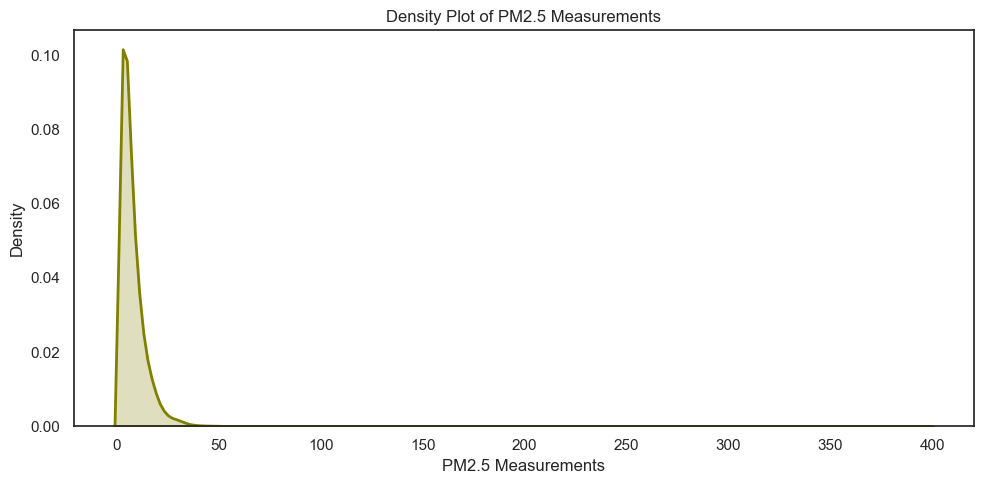

In [18]:
#Removing them
df_clean = df[df['PM25_ugm3'] <= 400].dropna()

plt.figure(figsize=(10,5))
sns.kdeplot(df_clean['PM25_ugm3'], fill=True, color='olive', linewidth=2)

plt.xlabel('PM2.5 Measurements')
plt.ylabel('Density')
plt.title('Density Plot of PM2.5 Measurements')

plt.tight_layout()
plt.show()

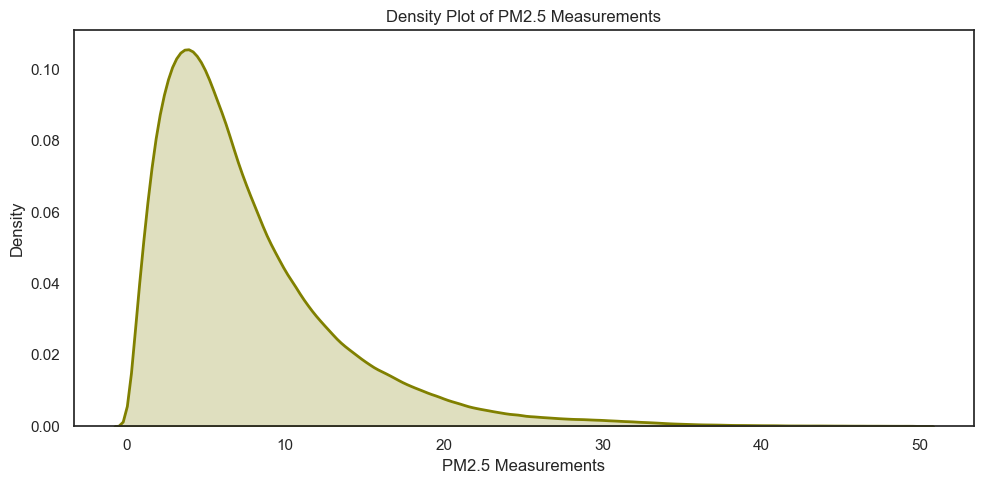

In [19]:
#Smaller density 
df_clean = df[df['PM25_ugm3'] <= 50].dropna()

plt.figure(figsize=(10,5))
sns.kdeplot(df_clean['PM25_ugm3'], fill=True, color='olive', linewidth=2)

plt.xlabel('PM2.5 Measurements')
plt.ylabel('Density')
plt.title('Density Plot of PM2.5 Measurements')

plt.tight_layout()
plt.show()

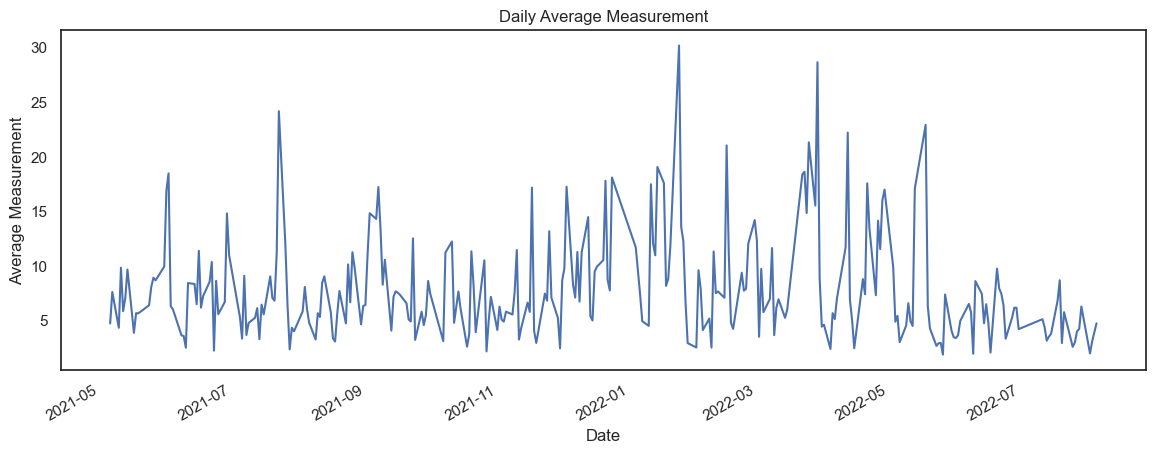

In [20]:
# Average measurement over time 
daily_avg = df_clean.groupby('date')['PM25_ugm3'].mean()
daily_avg.plot(figsize=(14,5))
plt.xlabel("Date")
plt.ylabel("Average Measurement")
plt.title("Daily Average Measurement")
plt.show()

In [21]:
# Heatmap hour
pivot = df_clean.pivot_table(
    values='PM25_ugm3',
    index='date',
    columns='hour',
    aggfunc='mean'
)

plt.figure(figsize=(14,10))
sns.heatmap(pivot, cmap="viridis")

plt.xlabel("Hour")
plt.ylabel("Date")
plt.title("Measurements by Date and Hour")
plt.show()

KeyError: 'hour'

Location

In [ ]:
#Approximate km^2 area car drove around
lat_min = df['latitude'].min()
lat_max = df['latitude'].max()
lon_min = df['longitude'].min()
lon_max = df['longitude'].max()

# Very rough conversion is 1 degree lat/long approxes to 111km
# Approximate conversion
lat_km = (lat_max - lat_min) * 111
mean_lat = df['latitude'].mean()
lon_km = (lon_max - lon_min) * 111 * math.cos(math.radians(mean_lat)) #times the cos(lat)

# Approximate area
area_km2 = lat_km * lon_km

print(f"Approximate area covered by car: {area_km2:.2f} km²")

In [ ]:
#lat/long by pm2.5

plt.figure(figsize=(8,6))
scatter = sns.scatterplot(
    x='longitude', 
    y='latitude', 
    hue='PM25_ugm3',       # color by recording
    palette='viridis',  # colormap palette
    data=df_clean,
    s=20               # size of points
)

plt.title("Latitude vs Longitude colored by Metric")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 2.2 Weather data understanding

In [23]:
# ==================================================
# 2.1 Weather data: loading and understanding
# ==================================================

from pathlib import Path
import pandas as pd

# -----------------------------
# Load weather data
# -----------------------------
weather_path = Path().resolve().parent / "data" / "external" / "airport_weather.csv"

# The first 25 lines are metadata; the real header is on line 26
weather_df = pd.read_csv(weather_path, skiprows=25)

print("Weather data loaded.")
print(f"Shape: {weather_df.shape}")
display(weather_df.head())


# -----------------------------
# Basic structure checks
# -----------------------------
print("\nColumn names:")
print(weather_df.columns.tolist())

print("\nData types:")
print(weather_df.dtypes)

print("\nDuplicate rows:")
print(weather_df.duplicated().sum())


# -----------------------------
# Parse date column
# -----------------------------
weather_df["date"] = pd.to_datetime(
    weather_df["date"],
    format="%d-%b-%Y",
    errors="coerce"
)

print("\nMissing dates after parsing:")
print(weather_df["date"].isna().sum())


# -----------------------------
# Keep only project-relevant dates:
# May 2021 to August 2022
# -----------------------------
start_date = pd.Timestamp("2021-05-01")
end_date = pd.Timestamp("2022-08-31")

weather_filtered = weather_df[
    weather_df["date"].between(start_date, end_date)
].reset_index(drop=True)

print("\nFiltered to project-relevant period (May 2021 to August 2022).")
print(f"Shape: {weather_filtered.shape}")
display(weather_filtered.head())


# -----------------------------
# Remove unnecessary columns
# -----------------------------
cols_to_drop = [
    "ind", "ind.1", "igmin", "ind.2", "gmin", "ind.3", "ind.4", "ind.5", "dos", "smd_wd", "smd_md", "smd_pd", "cbl", "soil"
]

existing_drop_cols = [col for col in cols_to_drop if col in weather_filtered.columns]
weather_filtered = weather_filtered.drop(columns=existing_drop_cols)

print("\nDropped unnecessary columns:")
print(existing_drop_cols)

print("\nRemaining columns:")
print(weather_filtered.columns.tolist())


# -----------------------------
# Coerce remaining non-date columns to numeric where possible
# -----------------------------
for col in weather_filtered.columns:
    if col != "date":
        weather_filtered[col] = pd.to_numeric(weather_filtered[col], errors="coerce")


# -----------------------------
# Variable overview
# -----------------------------
print("\nSummary statistics (numeric variables):")
display(weather_filtered.describe())

print("\nNon-numeric columns:")
non_numeric_cols = weather_filtered.select_dtypes(exclude="number").columns.tolist()
print(non_numeric_cols)


# -----------------------------
# Time coverage
# -----------------------------
print("\nTime coverage:")
print(f"Start date: {weather_filtered['date'].min()}")
print(f"End date:   {weather_filtered['date'].max()}")
print(f"Number of unique dates: {weather_filtered['date'].nunique()}")


# -----------------------------
# Granularity check
# -----------------------------
date_dupes = weather_filtered.duplicated(subset=["date"]).sum()

print("\nGranularity check:")
print(f"Duplicate dates: {date_dupes}")

if date_dupes == 0:
    print("Granularity looks correct: one row per date.")
else:
    print("Warning: there are multiple rows for some dates.")


# -----------------------------
# Missingness
# -----------------------------
missing_summary = (
    weather_filtered.isna()
    .sum()
    .to_frame(name="n_missing")
    .assign(pct_missing=lambda x: 100 * x["n_missing"] / len(weather_filtered))
    .sort_values("n_missing", ascending=False)
)

print("\nMissingness summary:")
display(missing_summary)


# -----------------------------
# Candidate weather predictors
# -----------------------------
candidate_weather_vars = [
    "rain", "maxtp", "mintp", "wdsp", "hm", "hg", "sun", "g_rad", "pe", "evap"
]

existing_weather_vars = [col for col in candidate_weather_vars if col in weather_filtered.columns]

print("\nCandidate weather variables summary:")
display(weather_filtered[existing_weather_vars].describe())

Weather data loaded.
Shape: (30740, 26)


,date,ind,maxtp,ind.1,mintp,igmin,gmin,ind.2,rain,cbl,...,hg,sun,dos,g_rad,soil,pe,evap,smd_wd,smd_md,smd_pd
0,01-jan-1942,0,9.7,0,6.8,0,4.7,2,0.0,1020.3,...,,0.0,0,,,1.1,1.4,,,
1,02-jan-1942,0,9.9,0,7.9,0,6.7,0,0.1,1016.2,...,,0.0,0,,,0.7,0.9,,,
2,03-jan-1942,0,11.2,0,8.9,0,7.2,0,1.5,1006.8,...,,0.1,0,,,0.5,0.6,,,
3,04-jan-1942,0,9.2,0,2.7,0,3.4,0,3.5,1001.5,...,,0.6,0,,,0.6,0.7,,,
4,05-jan-1942,0,3.5,1,-0.8,0,0.0,0,0.6,1013.4,...,,3.4,0,,,0.6,0.7,,,



Column names:
['date', 'ind', 'maxtp', 'ind.1', 'mintp', 'igmin', 'gmin', 'ind.2', 'rain', 'cbl', 'wdsp', 'ind.3', 'hm', 'ind.4', 'ddhm', 'ind.5', 'hg', 'sun', 'dos', 'g_rad', 'soil', 'pe', 'evap', 'smd_wd', 'smd_md', 'smd_pd']

Data types:
date       object
ind         int64
maxtp     float64
ind.1       int64
mintp     float64
igmin       int64
gmin       object
ind.2       int64
rain      float64
cbl       float64
wdsp      float64
ind.3       int64
hm         object
ind.4       int64
ddhm       object
ind.5       int64
hg         object
sun       float64
dos        object
g_rad      object
soil       object
pe        float64
evap       object
smd_wd     object
smd_md     object
smd_pd     object
dtype: object

Duplicate rows:
0

Missing dates after parsing:
0

Filtered to project-relevant period (May 2021 to August 2022).
Shape: (488, 26)


,date,ind,maxtp,ind.1,mintp,igmin,gmin,ind.2,rain,cbl,...,hg,sun,dos,g_rad,soil,pe,evap,smd_wd,smd_md,smd_pd
0,2021-05-01,0,11.3,1,-1.9,1,-4.4,2,0.0,1008.3,...,12,7.6,0,1622,9.300,2.0,2.8,44.4,44.4,44.1
1,2021-05-02,0,12.9,0,2.0,1,-1.7,2,0.0,1008.7,...,16,7.5,0,1888,11.125,2.5,3.5,45.9,45.9,45.7
2,2021-05-03,0,12.5,0,5.1,0,2.1,0,10.2,991.5,...,38,2.4,0,1024,9.775,1.7,2.6,36.6,36.6,36.6
3,2021-05-04,0,10.1,0,2.6,0,3.9,0,1.3,992.0,...,36,8.0,0,1823,8.425,2.2,4.0,36.8,36.8,36.9
4,2021-05-05,0,10.6,0,0.3,0,0.5,0,2.7,1000.0,...,25,6.4,0,1588,7.775,1.9,2.9,35.4,35.4,35.6



Dropped unnecessary columns:
['ind', 'ind.1', 'igmin', 'ind.2', 'gmin', 'ind.3', 'ind.4', 'ind.5', 'dos', 'smd_wd', 'smd_md', 'smd_pd', 'cbl', 'soil']

Remaining columns:
['date', 'maxtp', 'mintp', 'rain', 'wdsp', 'hm', 'ddhm', 'hg', 'sun', 'g_rad', 'pe', 'evap']

Summary statistics (numeric variables):


,date,maxtp,mintp,rain,wdsp,hm,ddhm,hg,sun,g_rad,pe,evap
count,488,488.000000,488.000000,488.000000,488.000000,488.000000,488.000000,488.000000,488.000000,488.000000,488.000000,488.000000
mean,2021-12-30 12:00:00,15.290574,7.069057,1.611066,8.550820,15.229508,207.479508,22.743852,4.629303,1188.885246,1.851025,2.605533
min,2021-05-01 00:00:00,3.800000,-4.400000,0.000000,2.600000,5.000000,0.000000,9.000000,0.000000,20.000000,0.000000,0.000000
25%,2021-08-30 18:00:00,11.400000,3.400000,0.000000,6.000000,11.000000,140.000000,17.000000,1.000000,476.250000,0.900000,1.200000
50%,2021-12-30 12:00:00,15.600000,7.600000,0.100000,8.000000,14.000000,250.000000,21.000000,4.000000,1119.000000,1.800000,2.500000
75%,2022-05-01 06:00:00,19.000000,10.525000,1.300000,10.525000,18.000000,280.000000,28.000000,7.300000,1764.500000,2.700000,3.900000
max,2022-08-31 00:00:00,29.100000,16.900000,26.900000,24.400000,39.000000,350.000000,54.000000,15.500000,2960.000000,4.600000,6.100000
std,NaN,4.926336,4.489628,3.580187,3.319688,5.307446,87.647790,7.910820,3.980649,763.301036,1.119364,1.597994



Non-numeric columns:
['date']

Time coverage:
Start date: 2021-05-01 00:00:00
End date:   2022-08-31 00:00:00
Number of unique dates: 488

Granularity check:
Duplicate dates: 0
Granularity looks correct: one row per date.

Missingness summary:


,n_missing,pct_missing
date,0,0.0
maxtp,0,0.0
mintp,0,0.0
rain,0,0.0
wdsp,0,0.0
hm,0,0.0
ddhm,0,0.0
hg,0,0.0
sun,0,0.0
g_rad,0,0.0



Candidate weather variables summary:


,rain,maxtp,mintp,wdsp,hm,hg,sun,g_rad,pe,evap
count,488.000000,488.000000,488.000000,488.000000,488.000000,488.000000,488.000000,488.000000,488.000000,488.000000
mean,1.611066,15.290574,7.069057,8.550820,15.229508,22.743852,4.629303,1188.885246,1.851025,2.605533
std,3.580187,4.926336,4.489628,3.319688,5.307446,7.910820,3.980649,763.301036,1.119364,1.597994
min,0.000000,3.800000,-4.400000,2.600000,5.000000,9.000000,0.000000,20.000000,0.000000,0.000000
25%,0.000000,11.400000,3.400000,6.000000,11.000000,17.000000,1.000000,476.250000,0.900000,1.200000
50%,0.100000,15.600000,7.600000,8.000000,14.000000,21.000000,4.000000,1119.000000,1.800000,2.500000
75%,1.300000,19.000000,10.525000,10.525000,18.000000,28.000000,7.300000,1764.500000,2.700000,3.900000
max,26.900000,29.100000,16.900000,24.400000,39.000000,54.000000,15.500000,2960.000000,4.600000,6.100000


### 2.3 Traffic data understanding

In [24]:
# ==================================================
# 2.2 Traffic data: loading and understanding
# ==================================================

from pathlib import Path
import pandas as pd

# -----------------------------
# Load traffic data
# -----------------------------
traffic_path = Path().resolve().parent / "data" / "external" / "traffic_daily_by_region_from_sites.csv"

traffic_df = pd.read_csv(traffic_path)

print("Traffic data loaded.")
print(f"Shape: {traffic_df.shape}")
display(traffic_df.head())


# -----------------------------
# Basic structure checks
# -----------------------------
print("\nColumn names:")
print(traffic_df.columns.tolist())

print("\nData types:")
print(traffic_df.dtypes)

print("\nDuplicate rows:")
print(traffic_df.duplicated().sum())


# -----------------------------
# Parse date column
# -----------------------------
traffic_df["date"] = pd.to_datetime(traffic_df["date"], errors="coerce")

print("\nMissing dates after parsing:")
print(traffic_df["date"].isna().sum())


# -----------------------------
# Variable overview
# -----------------------------
print("\nSummary statistics (numeric variables):")
display(traffic_df.describe())

print("\nUnique regions:")
print(sorted(traffic_df["Region"].dropna().unique()))
print(f"Number of unique regions: {traffic_df['Region'].nunique()}")


# -----------------------------
# Time coverage
# -----------------------------
print("\nTime coverage:")
print(f"Start date: {traffic_df['date'].min()}")
print(f"End date:   {traffic_df['date'].max()}")
print(f"Number of unique dates: {traffic_df['date'].nunique()}")


# -----------------------------
# Granularity check
# -----------------------------
region_day_dupes = traffic_df.duplicated(subset=["date", "Region"]).sum()

print("\nGranularity check:")
print(f"Duplicate date-region pairs: {region_day_dupes}")

if region_day_dupes == 0:
    print("Granularity looks correct: one row per day per region.")
else:
    print("Warning: there are multiple rows for some day-region pairs.")


# -----------------------------
# Missingness
# -----------------------------
missing_summary = (
    traffic_df.isna()
    .sum()
    .to_frame(name="n_missing")
    .assign(pct_missing=lambda x: 100 * x["n_missing"] / len(traffic_df))
    .sort_values("n_missing", ascending=False)
)

print("\nMissingness summary:")
display(missing_summary)


# -----------------------------
# Quick understanding of key variables
# -----------------------------
key_vars = [
    "mean_daily_site_volume",
    "median_daily_site_volume",
    "total_daily_site_volume",
    "n_sites"
]

existing_key_vars = [col for col in key_vars if col in traffic_df.columns]

print("\nKey traffic variables summary:")
display(traffic_df[existing_key_vars].describe())


# -----------------------------
# Region-level coverage snapshot
# -----------------------------
region_summary = (
    traffic_df.groupby("Region", as_index=False)
    .agg(
        n_days=("date", "nunique"),
        mean_traffic=("mean_daily_site_volume", "mean"),
        mean_sites=("n_sites", "mean")
    )
    .sort_values("Region")
)

print("\nRegion-level summary:")
display(region_summary)


Traffic data loaded.
Shape: (3416, 6)


,date,Region,mean_daily_site_volume,median_daily_site_volume,total_daily_site_volume,n_sites
0,2021-05-01,CCITY,12098.288136,10559.5,1427598,118
1,2021-05-01,DCC1,17020.015152,14865.5,1123321,66
2,2021-05-01,IRE,16739.429319,14867.0,3197231,191
3,2021-05-01,IRE3,18313.857143,17985.0,512788,28
4,2021-05-01,NCITY,14283.241026,14182.0,2785232,195



Column names:
['date', 'Region', 'mean_daily_site_volume', 'median_daily_site_volume', 'total_daily_site_volume', 'n_sites']

Data types:
date                         object
Region                       object
mean_daily_site_volume      float64
median_daily_site_volume    float64
total_daily_site_volume       int64
n_sites                       int64
dtype: object

Duplicate rows:
0

Missing dates after parsing:
0

Summary statistics (numeric variables):


,date,mean_daily_site_volume,median_daily_site_volume,total_daily_site_volume,n_sites
count,3416,3416.000000,3416.000000,3.416000e+03,3416.000000
mean,2021-12-30 11:59:59.999999744,17305.512849,15798.784251,2.127190e+06,125.476874
min,2021-05-01 00:00:00,385.533333,296.000000,1.181500e+04,1.000000
25%,2021-08-30 18:00:00,15420.018133,14394.750000,1.519529e+06,69.000000
50%,2021-12-30 12:00:00,17091.416667,15794.500000,2.002592e+06,120.000000
75%,2022-05-01 06:00:00,19196.939659,17343.375000,2.959881e+06,193.000000
max,2022-08-31 00:00:00,29575.000000,29575.000000,4.449082e+06,211.000000
std,NaN,3057.349864,2575.027451,1.055490e+06,58.852308



Unique regions:
['CCITY', 'DCC1', 'IRE', 'IRE3', 'NCITY', 'SCITY', 'WCITY1']
Number of unique regions: 7

Time coverage:
Start date: 2021-05-01 00:00:00
End date:   2022-08-31 00:00:00
Number of unique dates: 488

Granularity check:
Duplicate date-region pairs: 0
Granularity looks correct: one row per day per region.

Missingness summary:


,n_missing,pct_missing
date,0,0.0
Region,0,0.0
mean_daily_site_volume,0,0.0
median_daily_site_volume,0,0.0
total_daily_site_volume,0,0.0
n_sites,0,0.0



Key traffic variables summary:


,mean_daily_site_volume,median_daily_site_volume,total_daily_site_volume,n_sites
count,3416.000000,3416.000000,3.416000e+03,3416.000000
mean,17305.512849,15798.784251,2.127190e+06,125.476874
std,3057.349864,2575.027451,1.055490e+06,58.852308
min,385.533333,296.000000,1.181500e+04,1.000000
25%,15420.018133,14394.750000,1.519529e+06,69.000000
50%,17091.416667,15794.500000,2.002592e+06,120.000000
75%,19196.939659,17343.375000,2.959881e+06,193.000000
max,29575.000000,29575.000000,4.449082e+06,211.000000



Region-level summary:


,Region,n_days,mean_traffic,mean_sites
0,CCITY,488,15992.524043,119.131148
1,DCC1,488,21158.914809,68.147541
2,IRE,488,18994.340880,196.782787
3,IRE3,488,18285.388752,27.432377
4,NCITY,488,16510.997807,199.520492
5,SCITY,488,14229.644722,147.706967
6,WCITY1,488,15966.778928,119.616803


## 3. Data aggregation & preparation

### 3.1 Aggregate mobile PM2.5 measurements to a Dublin-day target

In [25]:
# ==================================================
# Air quality data: Step 2
# Aggregate mobile PM2.5 measurements to a Dublin-day target
# ==================================================

from pathlib import Path
import pandas as pd

# -----------------------------
# 0. File paths
# -----------------------------
project_root = next(p for p in Path().resolve().parents if (p / "environment.yml").exists())

air_path = project_root / "data" / "raw" / "AirView_DublinCity_Measurements_ugm3.csv"

output_path = project_root / "data" / "raw" / "air_quality_daily_dublin_avg_pm25.csv"

# -----------------------------
# 1. Load only needed columns
# -----------------------------
air_df = pd.read_csv(
    air_path,
    usecols=["gps_timestamp", "latitude", "longitude", "PM25_ugm3"]
)

print("\nRaw air quality data shape:")
print(air_df.shape)
display(air_df.head())


# -----------------------------
# 2. Basic cleaning
# -----------------------------
air_df["gps_timestamp"] = pd.to_datetime(
    air_df["gps_timestamp"],
    errors="coerce",
    utc=True
)

air_df = air_df[air_df["PM25_ugm3"] <= 400] #assume measurement errors

air_df = air_df.dropna(subset=["gps_timestamp", "latitude", "longitude", "PM25_ugm3"])

print("\nShape after basic cleaning:")
print(air_df.shape)


# -----------------------------
# 3. Aggregate over time
# -----------------------------
# Convert timestamp to calendar day
air_df["date"] = air_df["gps_timestamp"].dt.date


# -----------------------------
# 4. Aggregate over location
# -----------------------------
# Decision:
# For each day, pool PM2.5 observations across all recorded Dublin locations
# and compute one Dublin-wide daily average PM2.5 value.

# Create an approximate location identifier for transparency
air_df["location_id"] = (
    air_df["latitude"].round(5).astype(str) + "_" +
    air_df["longitude"].round(5).astype(str)
)

air_daily = (
    air_df.groupby("date", as_index=False)
    .agg(
        dublin_daily_avg_pm25=("PM25_ugm3", "mean"),
        pm25_count=("PM25_ugm3", "size"),
        pm25_min=("PM25_ugm3", "min"),
        pm25_max=("PM25_ugm3", "max"),
        n_unique_locations=("location_id", "nunique")
    )
    .sort_values("date")
    .reset_index(drop=True)
)

print("\nFinal aggregated dataset shape:")
print(air_daily.shape)

display(air_daily.head())


# -----------------------------
# 5. Save output
# -----------------------------
output_path.parent.mkdir(parents=True, exist_ok=True)
air_daily.to_csv(output_path, index=False)

print(f"\nSaved aggregated daily air quality data to:\n{output_path}")


Raw air quality data shape:
(5030143, 4)


,gps_timestamp,latitude,longitude,PM25_ugm3
0,2022-04-07 14:56:36 UTC,53.346434,-6.263997,4.927
1,2022-04-07 14:56:37 UTC,53.346434,-6.263997,4.240
2,2022-04-07 14:56:38 UTC,53.346434,-6.263997,4.204
3,2022-04-07 14:56:39 UTC,53.346434,-6.263997,3.410
4,2022-04-07 14:56:40 UTC,53.346434,-6.263997,4.003



Shape after basic cleaning:
(4940149, 4)

Final aggregated dataset shape:
(286, 6)


,date,dublin_daily_avg_pm25,pm25_count,pm25_min,pm25_max,n_unique_locations
0,2021-05-06,4.903776,7518,0.702,107.655,5684
1,2021-05-07,7.940760,13204,1.023,289.730,7900
2,2021-05-10,4.443267,1566,0.195,101.522,1112
3,2021-05-11,9.881657,2964,3.730,69.970,1764
4,2021-05-12,5.863840,650,0.596,31.540,522



Saved aggregated daily air quality data to:
C:\Users\ellen\Documents\GitHub\dublin-air-quality-forecasting\data\raw\air_quality_daily_dublin_avg_pm25.csv


#### 3.1.1 By Location

In [10]:
# ==================================================
# Air quality data: Step 2.1 (by location)
# Aggregate mobile PM2.5 measurements to Dublin location
# ==================================================

from pathlib import Path
import pandas as pd

# -----------------------------
# 0. File paths
# -----------------------------
project_root = next(p for p in Path().resolve().parents if (p / "environment.yml").exists())

air_path = project_root / "data" / "raw" / "AirView_DublinCity_Measurements_ugm3.csv"

output_path = project_root / "data" / "processed" / "location_air_quality_daily_dublin_avg_pm25.csv"

# -----------------------------
# 1. Load only needed columns
# -----------------------------
air_df = pd.read_csv(
    air_path,
    usecols=["gps_timestamp", "latitude", "longitude", "PM25_ugm3"]
)

# -----------------------------
# 2. Basic cleaning
# -----------------------------
air_df["gps_timestamp"] = pd.to_datetime(
    air_df["gps_timestamp"],
    errors="coerce",
    utc=True
)

air_df = air_df[air_df["PM25_ugm3"] <= 400] #assume measurement errors

air_df = air_df.dropna(subset=["gps_timestamp", "latitude", "longitude", "PM25_ugm3"])

# -----------------------------
# 3. Aggregate over time
# -----------------------------
# Convert timestamp to calendar day
air_df["date"] = air_df["gps_timestamp"].dt.date

# -----------------------------
# 4. Aggregate over location
        # North or South of Liffey
# -----------------------------
# Decision: Based on location being north or south of the Liffey River 

# Liffey latitude
liffey_lat = 53.346565

# Mask north and south locations
north_loc = air_df['latitude'] > liffey_lat
south_loc = air_df['latitude'] < liffey_lat

# Create series
location_label = pd.Series(index=air_df.index, dtype=str)

location_label[north_loc] = 'north'
location_label[south_loc] = 'south'

# Assign back to dataframe
air_df['location_label'] = location_label

# Group by date and location label
air_daily_loc = (
    air_df.groupby(["date", "location_label"], as_index=False)
    .agg(
        dublin_daily_avg_pm25=("PM25_ugm3", "mean"),
        pm25_count=("PM25_ugm3", "size"),
        pm25_min=("PM25_ugm3", "min"),
        pm25_max=("PM25_ugm3", "max")
    )
    .sort_values(["date", "location_label"])
    .reset_index(drop=True)
)

print("\nFinal aggregated dataset shape:")
print(air_daily_loc.shape)

display(air_daily_loc.head())

# -----------------------------
# 5. Save output
# -----------------------------
output_path.parent.mkdir(parents=True, exist_ok=True)
air_daily_loc.to_csv(output_path, index=False)

print(f"\nSaved aggregated daily air quality data to:\n{output_path}")


Final aggregated dataset shape:
(534, 6)


,date,location_label,dublin_daily_avg_pm25,pm25_count,pm25_min,pm25_max
0,2021-05-06,north,8.427493,71,3.963,17.017
1,2021-05-06,south,4.870181,7447,0.702,107.655
2,2021-05-07,north,7.304802,6264,1.023,142.365
3,2021-05-07,south,8.514772,6940,1.356,289.730
4,2021-05-10,south,4.443267,1566,0.195,101.522



Saved aggregated daily air quality data to:
/Users/rosalielacroix/Desktop/GitHub/dublin-air-quality-forecasting/data/processed/location_air_quality_daily_dublin_avg_pm25.csv


### 3.2 Aggregate traffic measurements to a Dublin-day target

In [26]:
from pathlib import Path
import pandas as pd

# -----------------------------
# Paths
# -----------------------------
project_root = next(p for p in Path().resolve().parents if (p / "environment.yml").exists())

traffic_path = project_root / "data" / "external" / "traffic_daily_by_region_from_sites.csv"
traffic_output_path = project_root / "data" / "processed" / "traffic_daily_dublin_avg.csv"

# -----------------------------
# Load traffic data
# -----------------------------
traffic_df = pd.read_csv(traffic_path)
traffic_df["date"] = pd.to_datetime(traffic_df["date"], errors="coerce")

print("Raw traffic shape (region-day level):")
print(traffic_df.shape)
display(traffic_df.head())

# -----------------------------
# Aggregate from region-day to Dublin-day
# -----------------------------
# Decision:
# The PM2.5 target is a Dublin-wide daily average.
# To align traffic to that same spatial unit, aggregate region-level traffic
# to one Dublin-wide traffic summary per day.

traffic_dublin_daily = (
    traffic_df
    .groupby("date", as_index=False)
    .agg(
        dublin_daily_mean_site_traffic=("mean_daily_site_volume", "mean"),
        dublin_daily_median_site_traffic=("median_daily_site_volume", "mean"),
        dublin_daily_total_traffic=("total_daily_site_volume", "sum"),
        dublin_daily_n_sites=("n_sites", "sum"),
        dublin_daily_n_regions=("Region", "nunique")
    )
    .sort_values("date")
    .reset_index(drop=True)
)

print("\nTraffic shape after spatial aggregation to Dublin-day:")
print(traffic_dublin_daily.shape)
display(traffic_dublin_daily.head())

# -----------------------------
# Save processed Dublin-level traffic data
# -----------------------------
traffic_output_path.parent.mkdir(parents=True, exist_ok=True)
traffic_dublin_daily.to_csv(traffic_output_path, index=False)

print(f"\nSaved processed traffic data to:\n{traffic_output_path}")

Raw traffic shape (region-day level):
(3416, 6)


,date,Region,mean_daily_site_volume,median_daily_site_volume,total_daily_site_volume,n_sites
0,2021-05-01,CCITY,12098.288136,10559.5,1427598,118
1,2021-05-01,DCC1,17020.015152,14865.5,1123321,66
2,2021-05-01,IRE,16739.429319,14867.0,3197231,191
3,2021-05-01,IRE3,18313.857143,17985.0,512788,28
4,2021-05-01,NCITY,14283.241026,14182.0,2785232,195



Traffic shape after spatial aggregation to Dublin-day:
(488, 6)


,date,dublin_daily_mean_site_traffic,dublin_daily_median_site_traffic,dublin_daily_total_traffic,dublin_daily_n_sites,dublin_daily_n_regions
0,2021-05-01,14966.243226,14037.571429,12507607,864,7
1,2021-05-02,12794.240957,11572.857143,10665395,864,7
2,2021-05-03,11436.567791,10586.285714,9516882,863,7
3,2021-05-04,16300.696407,15371.500000,13630512,863,7
4,2021-05-05,16559.577491,15467.285714,13936738,863,7



Saved processed traffic data to:
C:\Users\ellen\Documents\GitHub\dublin-air-quality-forecasting\data\processed\traffic_daily_dublin_avg.csv


#### 3.2.1 By location

In [7]:
# ==================================================
# Traffic data (by location)
# Aggregate traffic patterns by location
# ==================================================

from pathlib import Path
import pandas as pd

# -----------------------------
# File paths
# -----------------------------
project_root = next(p for p in Path().resolve().parents if (p / "environment.yml").exists())

traffic_path = project_root / "data" / "external" / "traffic_daily_by_region_from_sites.csv"

output_path = project_root / "data" / "processed" / "traffic_daily_location_avg.csv"

# -----------------------------
# Load traffic data
# -----------------------------
traffic_df = pd.read_csv(traffic_path)
traffic_df["date"] = pd.to_datetime(traffic_df["date"], errors="coerce")

# -----------------------------
# Aggregate by NCITY and SCITY
# -----------------------------
n_s_city = (traffic_df['Region'] == 'NCITY') | (traffic_df['Region'] == 'SCITY')

traffic_location_daily = traffic_df[n_s_city].reset_index(drop=True)

traffic_location_daily = traffic_location_daily.rename(columns={'Region': 'location_label'})

traffic_location_daily['location_label'] = traffic_location_daily['location_label'].map({
    'NCITY': 'north',
    'SCITY': 'south'
})

print("\nTraffic shape after aggregation by location:")
print(traffic_location_daily.shape)
display(traffic_location_daily.head())

# -----------------------------
# Save processed Dublin-level traffic data by location
# -----------------------------
output_path.parent.mkdir(parents=True, exist_ok=True)
traffic_location_daily.to_csv(output_path, index=False)

print(f"\nSaved aggregated daily air quality data to:\n{output_path}")


Traffic shape after aggregation by location:
(976, 6)


,date,location_label,mean_daily_site_volume,median_daily_site_volume,total_daily_site_volume,n_sites
0,2021-05-01,north,14283.241026,14182.0,2785232,195
1,2021-05-01,south,11706.630137,11797.5,1709168,146
2,2021-05-02,north,12075.846154,11878.0,2354790,195
3,2021-05-02,south,10177.287671,10322.5,1485884,146
4,2021-05-03,north,11044.369231,11106.0,2153652,195



Saved aggregated daily air quality data to:
/Users/rosalielacroix/Desktop/GitHub/dublin-air-quality-forecasting/data/processed/traffic_daily_location_avg.csv


### 3.3 Preparing weather measurements

In [28]:
from pathlib import Path
import pandas as pd

# -----------------------------
# Paths
# -----------------------------
project_root = next(p for p in Path().resolve().parents if (p / "environment.yml").exists())

weather_path = project_root / "data" / "external" / "airport_weather.csv"
weather_output_path = project_root / "data" / "processed" / "weather_daily_prepared.csv"

# -----------------------------
# Load raw weather data
# -----------------------------
weather_df = pd.read_csv(weather_path, skiprows=25)

weather_df["date"] = pd.to_datetime(
    weather_df["date"],
    format="%d-%b-%Y",
    errors="coerce"
)

print("Raw weather shape:")
print(weather_df.shape)
display(weather_df.head())

# -----------------------------
# Keep only project period
# -----------------------------
start_date = pd.Timestamp("2021-05-01")
end_date = pd.Timestamp("2022-08-31")

weather_df = weather_df[weather_df["date"].between(start_date, end_date)].copy()

# -----------------------------
# Drop unnecessary columns
# -----------------------------
cols_to_drop = [
    "ind", "ind.1", "igmin", "ind.2", "gmin", "ind.3", "ind.4",
    "ddhm", "ind.5", "dos", "smd_wd", "smd_md", "smd_pd", "cbl", "soil"
]
existing_drop_cols = [col for col in cols_to_drop if col in weather_df.columns]
weather_df = weather_df.drop(columns=existing_drop_cols)

# -----------------------------
# Coerce non-date columns to numeric
# -----------------------------
for col in weather_df.columns:
    if col != "date":
        weather_df[col] = pd.to_numeric(weather_df[col], errors="coerce")

# -----------------------------
# Keep one row per date
# -----------------------------
weather_daily = (
    weather_df
    .drop_duplicates(subset=["date"])
    .sort_values("date")
    .reset_index(drop=True)
)

print("\nPrepared weather shape:")
print(weather_daily.shape)
display(weather_daily.head())

print("\nDuplicate dates:")
print(weather_daily.duplicated(subset=["date"]).sum())

# -----------------------------
# Save prepared weather data
# -----------------------------
weather_output_path.parent.mkdir(parents=True, exist_ok=True)
weather_daily.to_csv(weather_output_path, index=False)

print(f"\nSaved prepared weather data to:\n{weather_output_path}")

Raw weather shape:
(30740, 26)


,date,ind,maxtp,ind.1,mintp,igmin,gmin,ind.2,rain,cbl,...,hg,sun,dos,g_rad,soil,pe,evap,smd_wd,smd_md,smd_pd
0,1942-01-01,0,9.7,0,6.8,0,4.7,2,0.0,1020.3,...,,0.0,0,,,1.1,1.4,,,
1,1942-01-02,0,9.9,0,7.9,0,6.7,0,0.1,1016.2,...,,0.0,0,,,0.7,0.9,,,
2,1942-01-03,0,11.2,0,8.9,0,7.2,0,1.5,1006.8,...,,0.1,0,,,0.5,0.6,,,
3,1942-01-04,0,9.2,0,2.7,0,3.4,0,3.5,1001.5,...,,0.6,0,,,0.6,0.7,,,
4,1942-01-05,0,3.5,1,-0.8,0,0.0,0,0.6,1013.4,...,,3.4,0,,,0.6,0.7,,,



Prepared weather shape:
(488, 11)


,date,maxtp,mintp,rain,wdsp,hm,hg,sun,g_rad,pe,evap
0,2021-05-01,11.3,-1.9,0.0,4.8,7,12,7.6,1622,2.0,2.8
1,2021-05-02,12.9,2.0,0.0,5.4,12,16,7.5,1888,2.5,3.5
2,2021-05-03,12.5,5.1,10.2,13.6,27,38,2.4,1024,1.7,2.6
3,2021-05-04,10.1,2.6,1.3,18.5,27,36,8.0,1823,2.2,4.0
4,2021-05-05,10.6,0.3,2.7,8.7,16,25,6.4,1588,1.9,2.9



Duplicate dates:
0

Saved prepared weather data to:
C:\Users\ellen\Documents\GitHub\dublin-air-quality-forecasting\data\processed\weather_daily_prepared.csv


## 4. Data merging

### 4.1 Overall Merge

In [29]:
from pathlib import Path
import pandas as pd

# -----------------------------
# Paths
# -----------------------------
project_root = next(p for p in Path().resolve().parents if (p / "environment.yml").exists())

air_path = project_root / "data" / "processed" / "air_quality_daily_dublin_avg_pm25.csv"
weather_path = project_root / "data" / "processed" / "weather_daily_prepared.csv"
traffic_path = project_root / "data" / "processed" / "traffic_daily_dublin_avg.csv"

output_path = project_root / "data" / "processed" / "merged_daily_dublin_avg_pm25_weather_traffic.csv"

# -----------------------------
# Load prepared datasets
# -----------------------------
air_df = pd.read_csv(air_path)
weather_daily = pd.read_csv(weather_path)
traffic_dublin_daily = pd.read_csv(traffic_path)

air_df["date"] = pd.to_datetime(air_df["date"], errors="coerce")
weather_daily["date"] = pd.to_datetime(weather_daily["date"], errors="coerce")
traffic_dublin_daily["date"] = pd.to_datetime(traffic_dublin_daily["date"], errors="coerce")

print("Air quality shape:")
print(air_df.shape)

print("\nWeather shape:")
print(weather_daily.shape)

print("\nTraffic shape:")
print(traffic_dublin_daily.shape)

# -----------------------------
# Merge datasets
# -----------------------------
merged_df = (
    air_df
    .merge(weather_daily, on="date", how="left")
    .merge(traffic_dublin_daily, on="date", how="left")
    .sort_values("date")
    .reset_index(drop=True)
)

# -----------------------------
# Add calendar features
# -----------------------------
merged_df["day_name"] = merged_df["date"].dt.day_name()
merged_df["day_of_week"] = merged_df["date"].dt.dayofweek
merged_df["is_weekend"] = merged_df["day_of_week"].isin([5, 6]).astype(int)

# Move key variables to the front
front_cols = [
    "date",
    "day_name",
    "day_of_week",
    "is_weekend",
    "dublin_daily_avg_pm25",
    "pm25_count",
    "n_unique_locations",
    "pm25_min",
    "pm25_max"
]
remaining_cols = [col for col in merged_df.columns if col not in front_cols]
merged_df = merged_df[front_cols + remaining_cols]

# -----------------------------
# Basic structure checks
# -----------------------------
print("\nMerged dataset shape:")
print(merged_df.shape)

print("\nColumns:")
print(merged_df.columns.tolist())

print("\nData types:")
print(merged_df.dtypes)

print("\nDuplicate dates:")
print(merged_df.duplicated(subset=["date"]).sum())

print("\nDate range:")
print(f"Start: {merged_df['date'].min()}")
print(f"End:   {merged_df['date'].max()}")

print("\nMissingness summary:")
missing_summary = (
    merged_df.isna()
    .sum()
    .to_frame(name="n_missing")
    .assign(pct_missing=lambda x: 100 * x["n_missing"] / len(merged_df))
    .sort_values("n_missing", ascending=False)
)
display(missing_summary)

print("\nNumeric summary:")
display(merged_df.describe())

print("\nHead of merged dataset:")
display(merged_df.head())

# -----------------------------
# Save merged dataset
# -----------------------------
output_path.parent.mkdir(parents=True, exist_ok=True)
merged_df.to_csv(output_path, index=False)

print(f"\nSaved merged dataset to:\n{output_path}")

Air quality shape:
(286, 6)

Weather shape:
(488, 11)

Traffic shape:
(488, 6)

Merged dataset shape:
(286, 24)

Columns:
['date', 'day_name', 'day_of_week', 'is_weekend', 'dublin_daily_avg_pm25', 'pm25_count', 'n_unique_locations', 'pm25_min', 'pm25_max', 'maxtp', 'mintp', 'rain', 'wdsp', 'hm', 'hg', 'sun', 'g_rad', 'pe', 'evap', 'dublin_daily_mean_site_traffic', 'dublin_daily_median_site_traffic', 'dublin_daily_total_traffic', 'dublin_daily_n_sites', 'dublin_daily_n_regions']

Data types:
date                                datetime64[ns]
day_name                                    object
day_of_week                                  int32
is_weekend                                   int64
dublin_daily_avg_pm25                      float64
pm25_count                                   int64
n_unique_locations                           int64
pm25_min                                   float64
pm25_max                                   float64
maxtp                                      fl

,n_missing,pct_missing
date,0,0.0
day_name,0,0.0
day_of_week,0,0.0
is_weekend,0,0.0
dublin_daily_avg_pm25,0,0.0
pm25_count,0,0.0
n_unique_locations,0,0.0
pm25_min,0,0.0
pm25_max,0,0.0
maxtp,0,0.0



Numeric summary:


,date,day_of_week,is_weekend,dublin_daily_avg_pm25,pm25_count,n_unique_locations,pm25_min,pm25_max,maxtp,mintp,...,hg,sun,g_rad,pe,evap,dublin_daily_mean_site_traffic,dublin_daily_median_site_traffic,dublin_daily_total_traffic,dublin_daily_n_sites,dublin_daily_n_regions
count,286,286.000000,286.0,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,...,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,2.860000e+02,286.000000,286.0
mean,2021-12-15 14:00:50.349650432,2.045455,0.0,8.095203,17273.657343,11078.629371,1.884619,247.381017,15.090909,6.919580,...,22.783217,4.528671,1172.664336,1.816434,2.562937,18307.139244,16749.672078,1.578613e+07,878.548951,7.0
min,2021-05-06 00:00:00,0.000000,0.0,1.925949,593.000000,203.000000,0.071000,23.215000,3.800000,-4.400000,...,9.000000,0.000000,50.000000,0.100000,0.100000,14793.572897,11461.428571,1.184910e+07,616.000000,7.0
25%,2021-08-24 06:00:00,1.000000,0.0,4.821168,13266.750000,8246.250000,0.407000,110.976000,11.125000,3.300000,...,17.000000,0.900000,460.000000,0.800000,1.100000,17793.585619,16181.142857,1.530086e+07,869.000000,7.0
50%,2021-12-09 12:00:00,2.000000,0.0,6.902611,18944.000000,11927.000000,0.824000,171.029000,15.600000,7.400000,...,21.500000,3.950000,1108.000000,1.800000,2.450000,18296.900762,16785.285714,1.576198e+07,880.500000,7.0
75%,2022-04-06 18:00:00,3.000000,0.0,9.925712,21743.250000,14375.000000,2.370250,287.372000,18.775000,10.375000,...,27.750000,7.250000,1781.250000,2.700000,3.800000,18973.427798,17428.785714,1.649859e+07,890.000000,7.0
max,2022-08-05 00:00:00,4.000000,0.0,30.384439,36847.000000,23694.000000,17.790000,1960.163000,29.100000,16.900000,...,54.000000,15.500000,2960.000000,4.500000,5.900000,20998.187277,19600.142857,1.759565e+07,917.000000,7.0
std,NaN,1.377016,0.0,4.766350,6071.516971,4522.050498,2.559029,243.924062,4.871844,4.498113,...,7.758766,3.941024,768.207661,1.124610,1.613699,962.354072,999.255732,9.109622e+05,24.444051,0.0



Head of merged dataset:


,date,day_name,day_of_week,is_weekend,dublin_daily_avg_pm25,pm25_count,n_unique_locations,pm25_min,pm25_max,maxtp,...,hg,sun,g_rad,pe,evap,dublin_daily_mean_site_traffic,dublin_daily_median_site_traffic,dublin_daily_total_traffic,dublin_daily_n_sites,dublin_daily_n_regions
0,2021-05-06,Thursday,3,0,4.903776,7518,5684,0.702,107.655,12.0,...,26,12.1,2489,2.8,4.4,17149.593217,16134.928571,14458493,865,7
1,2021-05-07,Friday,4,0,8.028253,13206,7902,1.023,764.816,11.1,...,21,11.3,2394,2.7,4.1,17920.225608,17037.785714,15133373,866,7
2,2021-05-10,Monday,0,0,4.443267,1566,1112,0.195,101.522,15.3,...,27,2.6,1312,2.4,3.5,16803.592495,15754.428571,14089843,864,7
3,2021-05-11,Tuesday,1,0,9.881657,2964,1764,3.730,69.970,14.1,...,23,13.0,2716,2.9,4.7,17419.522593,16005.642857,14678272,866,7
4,2021-05-12,Wednesday,2,0,5.863840,650,522,0.596,31.540,12.3,...,16,3.2,1620,1.9,2.8,17497.224895,16398.214286,14770830,865,7



Saved merged dataset to:
C:\Users\ellen\Documents\GitHub\dublin-air-quality-forecasting\data\processed\merged_daily_dublin_avg_pm25_weather_traffic.csv


### 4.2 Merge by Location and Date

In [13]:
# -----------------------------
# Paths
# -----------------------------
project_root = next(p for p in Path().resolve().parents if (p / "environment.yml").exists())

air_path = project_root / "data" / "processed" / "location_air_quality_daily_dublin_avg_pm25.csv"
weather_path = project_root / "data" / "processed" / "weather_daily_prepared.csv"
traffic_path = project_root / "data" / "processed" / "traffic_daily_location_avg.csv"

output_path = project_root / "data" / "processed" / "location_merged_daily_dublin_avg_pm25_weather_traffic.csv"

# -----------------------------
# Load prepared datasets
# -----------------------------
weather_daily = pd.read_csv(weather_path)
air_daily_loc = pd.read_csv(air_path)
traffic_daily_loc = pd.read_csv(traffic_path)

# Standardize date
air_daily_loc["date"] = pd.to_datetime(air_daily_loc["date"], errors="coerce")
weather_daily["date"] = pd.to_datetime(weather_daily["date"], errors="coerce")
traffic_daily_loc["date"] = pd.to_datetime(traffic_daily_loc["date"], errors="coerce")

print("Air quality shape:")
print(air_daily_loc.shape)

print("\nWeather shape:")
print(weather_daily.shape)

print("\nTraffic shape:")
print(traffic_daily_loc.shape)

# -----------------------------
# Merge datasets
# -----------------------------
# Merging data with north and south city information
merged_location_df = (
    air_daily_loc
    .merge(weather_daily, on="date", how="left")
    .merge(traffic_daily_loc, on=["date", "location_label"], how="left")
    .sort_values(["date", "location_label"])
    .reset_index(drop=True)
)

# -----------------------------
# Add calendar features
# -----------------------------
merged_location_df["day_name"] = merged_location_df["date"].dt.day_name()
merged_location_df["day_of_week"] = merged_location_df["date"].dt.dayofweek
merged_location_df["is_weekend"] = merged_location_df["day_of_week"].isin([5, 6]).astype(int)

# Move key variables to the front
front_cols = [
    "date",
    "day_name",
    "day_of_week",
    "is_weekend",
    "location_label",
    "dublin_daily_avg_pm25",
    "pm25_count",
    "pm25_min",
    "pm25_max"
]
remaining_cols = [col for col in merged_location_df.columns if col not in front_cols]
merged_location_df = merged_location_df[front_cols + remaining_cols]

# -----------------------------
# Basic structure checks
# -----------------------------
print("\nMerged dataset shape:")
print(merged_location_df.shape)

print("\nColumns:")
print(merged_location_df.columns.tolist())

print("\nData types:")
print(merged_location_df.dtypes)

print("\nDuplicate dates:")
print(merged_location_df.duplicated(subset=["date"]).sum())

print("\nDate range:")
print(f"Start: {merged_location_df['date'].min()}")
print(f"End:   {merged_location_df['date'].max()}")

print("\nMissingness summary:")
missing_summary = (
    merged_location_df.isna()
    .sum()
    .to_frame(name="n_missing")
    .assign(pct_missing=lambda x: 100 * x["n_missing"] / len(merged_location_df))
    .sort_values("n_missing", ascending=False)
)
display(missing_summary)

print("\nNumeric summary:")
display(merged_location_df.describe())

print("\nHead of merged dataset:")
display(merged_location_df.head())

# -----------------------------
# Save merged dataset
# -----------------------------
output_path.parent.mkdir(parents=True, exist_ok=True)
merged_location_df.to_csv(output_path, index=False)

print(f"\nSaved merged dataset to:\n{output_path}")

Air quality shape:
(534, 6)

Weather shape:
(488, 11)

Traffic shape:
(976, 6)

Merged dataset shape:
(534, 23)

Columns:
['date', 'day_name', 'day_of_week', 'is_weekend', 'location_label', 'dublin_daily_avg_pm25', 'pm25_count', 'pm25_min', 'pm25_max', 'maxtp', 'mintp', 'rain', 'wdsp', 'hm', 'hg', 'sun', 'g_rad', 'pe', 'evap', 'mean_daily_site_volume', 'median_daily_site_volume', 'total_daily_site_volume', 'n_sites']

Data types:
date                        datetime64[ns]
day_name                            object
day_of_week                          int32
is_weekend                           int64
location_label                      object
dublin_daily_avg_pm25              float64
pm25_count                           int64
pm25_min                           float64
pm25_max                           float64
maxtp                              float64
mintp                              float64
rain                               float64
wdsp                               float64
hm     

,n_missing,pct_missing
date,0,0.0
wdsp,0,0.0
total_daily_site_volume,0,0.0
median_daily_site_volume,0,0.0
mean_daily_site_volume,0,0.0
evap,0,0.0
pe,0,0.0
g_rad,0,0.0
sun,0,0.0
hg,0,0.0



Numeric summary:


,date,day_of_week,is_weekend,dublin_daily_avg_pm25,pm25_count,pm25_min,pm25_max,maxtp,mintp,rain,...,hm,hg,sun,g_rad,pe,evap,mean_daily_site_volume,median_daily_site_volume,total_daily_site_volume,n_sites
count,534,534.000000,534.0,534.000000,534.000000,534.000000,534.000000,534.000000,534.000000,534.000000,...,534.000000,534.000000,534.000000,534.000000,534.000000,534.000000,534.000000,534.000000,5.340000e+02,534.000000
mean,2021-12-15 07:08:45.842696448,2.035581,0.0,8.505879,9251.215356,2.407858,137.761908,15.164232,6.994569,1.372285,...,15.294007,22.737828,4.555618,1173.780899,1.816667,2.561610,16189.368254,15764.144195,2.809853e+06,171.749064
min,2021-05-06 00:00:00,0.000000,0.0,1.453694,14.000000,0.071000,4.300000,3.800000,-4.400000,0.000000,...,6.000000,9.000000,0.000000,50.000000,0.100000,0.100000,11678.500000,10050.500000,1.728418e+06,113.000000
25%,2021-08-25 00:00:00,1.000000,0.0,4.996782,1239.250000,0.595250,54.159250,11.200000,3.300000,0.000000,...,11.000000,17.000000,0.900000,479.000000,0.800000,1.100000,14943.774011,15178.125000,2.212638e+06,148.000000
50%,2021-12-08 00:00:00,2.000000,0.0,7.301144,8727.500000,1.276500,111.021000,15.700000,7.600000,0.100000,...,14.000000,21.000000,4.000000,1099.000000,1.750000,2.400000,16284.053115,15811.750000,2.455320e+06,150.000000
75%,2022-04-06 18:00:00,3.000000,0.0,10.775947,16122.500000,3.112500,196.438000,18.775000,10.400000,1.175000,...,18.000000,27.000000,7.300000,1784.000000,2.700000,3.875000,17379.870647,16404.000000,3.467868e+06,200.000000
max,2022-08-05 00:00:00,4.000000,0.0,30.677423,26224.000000,20.544000,399.148000,29.100000,16.900000,26.900000,...,39.000000,54.000000,15.500000,2960.000000,4.500000,5.900000,21367.072581,20221.000000,3.835536e+06,211.000000
std,NaN,1.383584,0.0,5.016312,7789.303842,2.956234,102.352195,4.860911,4.488776,3.230295,...,5.223493,7.809805,3.949873,765.679677,1.124719,1.611348,1491.863420,1015.818590,6.455842e+05,26.404288



Head of merged dataset:


,date,day_name,day_of_week,is_weekend,location_label,dublin_daily_avg_pm25,pm25_count,pm25_min,pm25_max,maxtp,...,hm,hg,sun,g_rad,pe,evap,mean_daily_site_volume,median_daily_site_volume,total_daily_site_volume,n_sites
0,2021-05-06,Thursday,3,0,north,8.427493,71,3.963,17.017,12.0,...,18,26,12.1,2489,2.8,4.4,16539.630769,15709.0,3225228,195
1,2021-05-06,Thursday,3,0,south,4.870181,7447,0.702,107.655,12.0,...,18,26,12.1,2489,2.8,4.4,13485.904762,14266.0,1982428,147
2,2021-05-07,Friday,4,0,north,7.304802,6264,1.023,142.365,11.1,...,15,21,11.3,2394,2.7,4.1,17299.764103,16766.0,3373454,195
3,2021-05-07,Friday,4,0,south,8.514772,6940,1.356,289.730,11.1,...,15,21,11.3,2394,2.7,4.1,14254.727891,15226.0,2095445,147
4,2021-05-10,Monday,0,0,south,4.443267,1566,0.195,101.522,15.3,...,19,27,2.6,1312,2.4,3.5,13311.061644,14123.0,1943415,146



Saved merged dataset to:
/Users/rosalielacroix/Desktop/GitHub/dublin-air-quality-forecasting/data/processed/location_merged_daily_dublin_avg_pm25_weather_traffic.csv


## 5. Feature selection

### 5.1 Correlation martrix TRAFFIC

### 5.2 Correlation martrix WEATHER

Finalised feature matrix object here: []

## 6. Baseline model
- (t-1)

## 7. Forecasting models

## 8. Inter-Model evaluation